# Importing libraries

In [1]:
import torch
from torchvision.models import vgg16, VGG16_Weights
from torch.optim import Adam
from torchvision import transforms 
import matplotlib.pyplot as plt
from PIL import Image

In [2]:
torch.device("cuda" if torch.cuda.is_available() else "cpu")

device(type='cuda')

In [3]:
model = vgg16(weights=VGG16_Weights.IMAGENET1K_V1).features.eval()

In [4]:
print(model)

Sequential(
  (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (1): ReLU(inplace=True)
  (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (3): ReLU(inplace=True)
  (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (5): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (6): ReLU(inplace=True)
  (7): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (8): ReLU(inplace=True)
  (9): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (10): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (11): ReLU(inplace=True)
  (12): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (13): ReLU(inplace=True)
  (14): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (15): ReLU(inplace=True)
  (16): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (17): Conv2d(256, 512, kernel_si

In [5]:
image = Image.open("image.png")

In [6]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

In [7]:
input_tensors = transform(image).unsqueeze(0).requires_grad_(True)


In [8]:
optimizer = Adam([input_tensors], lr=0.01)

In [26]:
# 4. Run the "Dreaming" loop
for i in range(50):
    optimizer.zero_grad()
    # Pass the image through the first few layers of the model
    out = input_tensors
    for layer in list(model)[:40]: # Pick how deep you want to go
        out = layer(out)
    
    # We want to maximize the activations of this layer
    loss = -out.norm() 
    loss.backward()
    optimizer.step()

In [27]:
import numpy

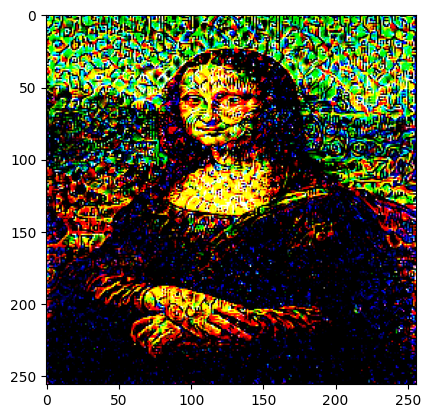

In [28]:
img_tensors = input_tensors.detach().cpu()

img_tensors = img_tensors.squeeze(0)

img_tensors = img_tensors.permute(1, 2, 0)

img_tensors = torch.clamp(img_tensors, 0, 1)


plt.imshow(img_tensors.numpy())